<a href="https://colab.research.google.com/github/LucasBarrosLK/Introdu-o-a-Ci-ncia-de-Dados/blob/main/An%C3%A1lise_Explorat%C3%B3ria_dos_Jogos_da_Steam_Fatores_Relacionados_ao_Sucesso_dos_Jogos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Análise Exploratória dos Jogos da Steam: Fatores Relacionados ao Sucesso dos Jogos

Objetivo

O objetivo deste trabalho é analisar dados de jogos publicados na plataforma Steam para identificar características relacionadas à popularidade e avaliação dos jogos, utilizando técnicas de análise exploratória de dados e visualização gráfica.

# Carregando o DATASET

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

plt.style.use('ggplot')

path = kagglehub.dataset_download("artermiloff/steam-games-dataset")
csv_path = os.path.join(path, "games_march2025_cleaned.csv")
df = pd.read_csv(csv_path)

df = df.dropna(subset=['price', 'positive', 'negative', 'recommendations', 'genres', 'developers'])
df = df.drop_duplicates()
df['is_free'] = df['price'] == 0

print(f"Dataset carregado: {len(df):,} jogos")

Using Colab cache for faster access to the 'steam-games-dataset' dataset.
Dataset carregado: 89,618 jogos


In [ ]:
csv_path = os.path.join(path, "games_march2025_cleaned.csv")

df = pd.read_csv(csv_path)


In [ ]:
print("Linhas e colunas:", df.shape)

Linhas e colunas: (89618, 48)


# Conhecendo e limpando os DADOS

In [ ]:
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,is_free
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473,True
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720,True
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366,True
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517,True
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89618 non-null  int64  
 1   name                      89618 non-null  object 
 2   release_date              89618 non-null  object 
 3   required_age              89618 non-null  int64  
 4   price                     89618 non-null  float64
 5   dlc_count                 89618 non-null  int64  
 6   detailed_description      89421 non-null  object 
 7   about_the_game            89398 non-null  object 
 8   short_description         89498 non-null  object 
 9   reviews                   10401 non-null  object 
 10  header_image              89618 non-null  object 
 11  website                   41114 non-null  object 
 12  support_url               44110 non-null  object 
 13  support_email             78798 non-null  object 
 14  window

In [ ]:
df.describe()

,appid,required_age,price,dlc_count,metacritic_score,achievements,recommendations,user_score,score_rank,positive,...,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
count,8.961800e+04,89618.000000,89618.000000,89618.000000,89618.000000,89618.000000,8.961800e+04,89618.000000,39.000000,8.961800e+04,...,8.961800e+04,89618.000000,8.961800e+04,89618.000000,89618.000000,8.961800e+04,89618.000000,8.961800e+04,89618.000000,89618.000000
mean,1.656904e+06,0.183624,7.309623,0.595583,2.903245,20.552333,1.009401e+03,0.032817,99.128205,1.269896e+03,...,1.149119e+02,5.032694,1.147559e+02,5.301814,4.558627,9.833994e+01,45.352418,1.315490e+03,5.231639,15.584581
std,9.168390e+05,1.725594,13.331073,15.351920,14.445358,163.562418,2.204815e+04,1.615149,0.695076,3.181441e+04,...,6.814748e+03,181.100334,8.806711e+03,189.591095,16.538036,5.717544e+03,40.685695,3.542370e+04,22.335358,444.277307
min,2.000000e+01,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,98.000000,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
25%,8.550525e+05,0.000000,0.990000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,99.000000,1.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
50%,1.524730e+06,0.000000,4.990000,0.000000,0.000000,5.000000,0.000000e+00,0.000000,99.000000,1.000000e+01,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,60.000000,1.500000e+01,-1.000000,-1.000000
75%,2.430852e+06,0.000000,9.990000,0.000000,0.000000,20.000000,0.000000e+00,0.000000,100.000000,5.800000e+01,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,84.000000,8.100000e+01,-1.000000,-1.000000
max,3.542350e+06,21.000000,999.980000,3427.000000,97.000000,9821.000000,4.401572e+06,100.000000,100.000000,7.480813e+06,...,1.462997e+06,18568.000000,1.462997e+06,18568.000000,100.000000,1.212356e+06,100.000000,8.632939e+06,100.000000,96473.000000


In [ ]:
df.isnull().sum()

,0
appid,0
name,0
release_date,0
required_age,0
price,0
dlc_count,0
detailed_description,197
about_the_game,220
short_description,120
reviews,79217


# PERGUNTA 1
Qual é a distribuição dos preços dos jogos?

A distribuição de preços é fortemente assimétrica à direita: aproximadamente 16% dos jogos são gratuitos, e a grande maioria dos jogos pagos se concentra na faixa de 0 a 10 dólares. A mediana de preço é 4,99, indicando que metade dos jogos custa menos que isso. Valores acima de 20 dólares são raros e representam outliers.

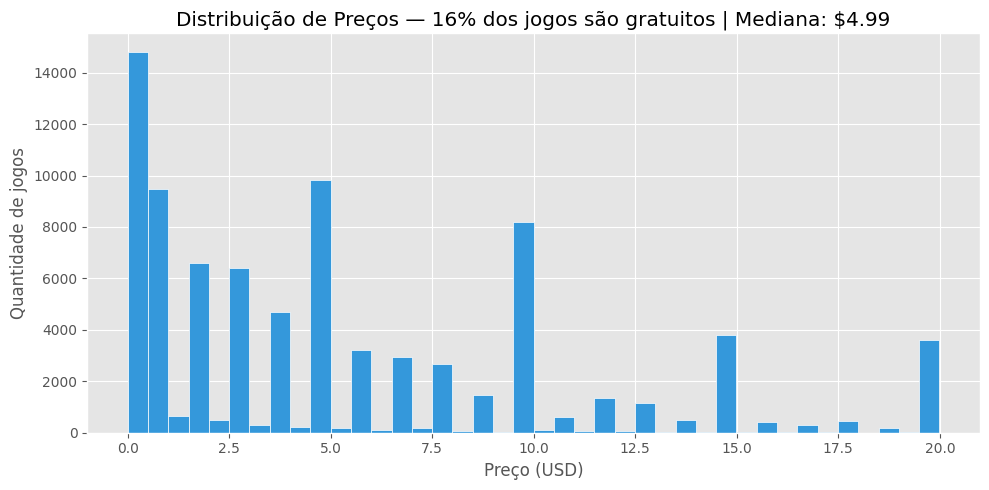

Jogos gratuitos: 14,160 (15.8%)
Preço mediano:   $4.99
Preço médio:     $7.31
Preço máximo:    $999.98


In [ ]:
df_plot = df[df['price'] <= df['price'].quantile(0.95)]
pct_gratis = (df['is_free'].mean() * 100)
mediana = df['price'].median()

plt.figure(figsize=(10, 5))
plt.hist(df_plot['price'], bins=40, color='#3498db', edgecolor='white')
plt.title(f'Distribuição de Preços — {pct_gratis:.0f}% dos jogos são gratuitos | Mediana: ${mediana}')
plt.xlabel('Preço (USD)')
plt.ylabel('Quantidade de jogos')
plt.tight_layout()
plt.show()

print(f"Jogos gratuitos: {df['is_free'].sum():,} ({pct_gratis:.1f}%)")
print(f"Preço mediano:   ${df['price'].median()}")
print(f"Preço médio:     ${df['price'].mean():.2f}")
print(f"Preço máximo:    ${df['price'].max():.2f}")

#Pergunta 2
 Qual o gênero com mais jogos catalogados?

 O gênero ACTION lidera com mais de 34,225 jogos, seguido por INDIE e ADVENTURE.
 Essa concentração é natural: ação é o gênero amplo que inclui desde shooters até jogos de plataforma, o que infla sua contagem. Indie segue essa lista pois a steam não possui curadoria rígida para publicação desses jogos, atraindo muitos desenvolvedores independentes.

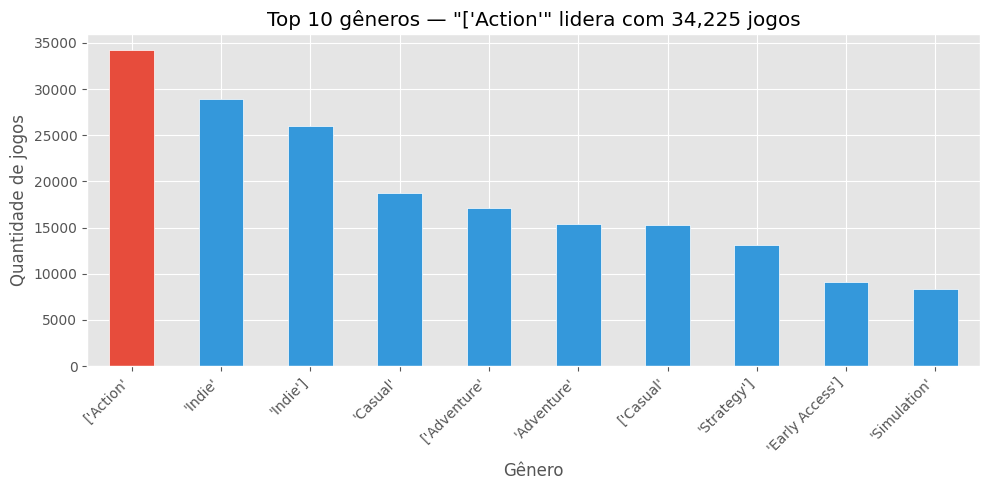

In [ ]:
generos = df['genres'].str.split(',').explode().str.strip()
top_generos = generos.value_counts().head(10)

cores = ['#e74c3c' if g == top_generos.index[0] else '#3498db' for g in top_generos.index]

plt.figure(figsize=(10, 5))
top_generos.plot(kind='bar', color=cores, edgecolor='white')
plt.title(f'Top 10 gêneros — "{top_generos.index[0]}" lidera com {top_generos.iloc[0]:,} jogos')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de jogos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Pergunta 3
Jogos gratuitos recebem mais avaliações positivas do que jogos pagos?

Com base na mediana de avaliações positivas (jogos com mais de 10 avaliações), jogos gratuitos têm mediana de 50 avaliações positivas contra 48 dos jogos pagos, uma diferença marginal. O boxplot mostra distribuições similares, com grande sobreposição. A conclusão é que ser gratuito não garante mais avaliações positivas por si só. O volume de jogadores é maior em jogos gratuitos, mas isso não se converte proporcionalmente em avaliações melhores, possivelmente porque jogadores que pagam tendem a ser mais engajados e propensos a avaliar.

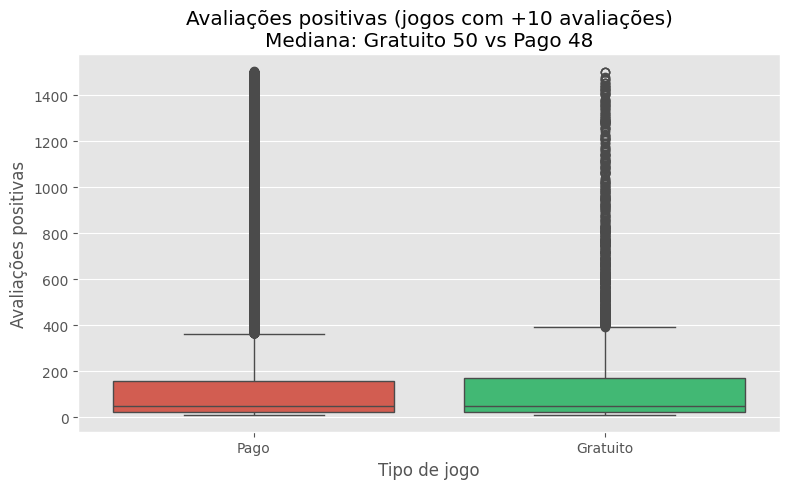

Jogos analisados — Gratuitos: 4,811 | Pagos: 34,517
Mediana gratuitos: 50
Mediana pagos:     48


In [ ]:

df_box = df[
    (df['positive'] > 10) &
    (df['positive'] < df['positive'].quantile(0.95))
]

mediana_gratis = df_box[df_box['is_free']]['positive'].median()
mediana_pago = df_box[~df_box['is_free']]['positive'].median()

plt.figure(figsize=(8, 5))
sns.boxplot(
    x='is_free',
    y='positive',
    data=df_box,
    hue='is_free',
    palette={True: '#2ecc71', False: '#e74c3c'},
    legend=False
)
plt.xticks([0, 1], ['Pago', 'Gratuito'])
plt.title(f'Avaliações positivas (jogos com +10 avaliações)\nMediana: Gratuito {mediana_gratis:,.0f} vs Pago {mediana_pago:,.0f}')
plt.xlabel('Tipo de jogo')
plt.ylabel('Avaliações positivas')
plt.tight_layout()
plt.show()

print(f"Jogos analisados — Gratuitos: {df_box['is_free'].sum():,} | Pagos: {(~df_box['is_free']).sum():,}")
print(f"Mediana gratuitos: {mediana_gratis:,.0f}")
print(f"Mediana pagos:     {mediana_pago:,.0f}")

#Pergunta 4  
Existe relação entre o preço de um jogo e a quantidade de avaliações positivas que ele recebe?

A correlação entre preço e avaliações positivas é de apenas 0,19, próxima de zero, indicando ausência de relação linear significativa. O scatter plot confirma isso: jogos de todos os preços acumulam tanto pouquíssimas quanto muitas avaliações positivas. Preço mais alto não garante mais avaliações positivas, e jogos gratuitos ou baratos dominam os extremos superiores de avaliação. O sucesso em avaliações parece depender mais de qualidade percebida, marketing e base de jogadores do que do preço praticado.

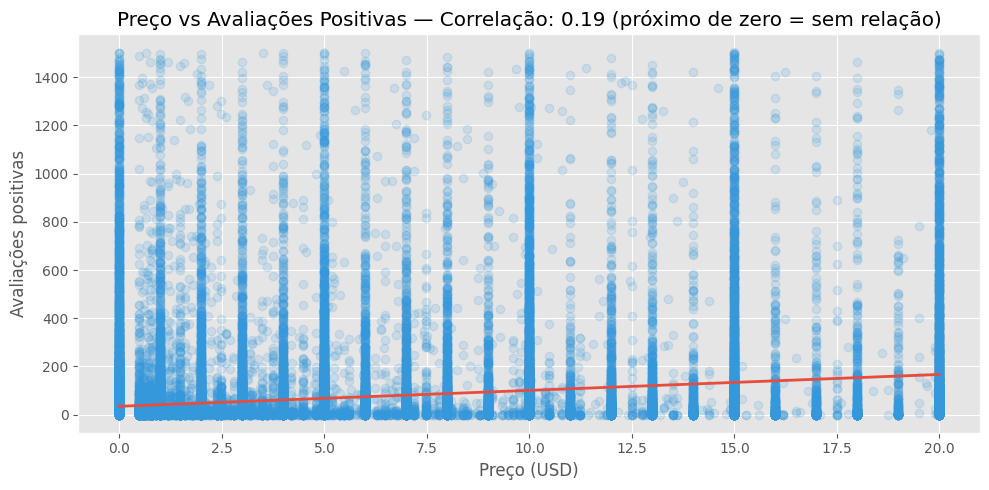

Correlação preço x avaliações positivas: 0.186


In [ ]:
df_scat = df[
    (df['price'] <= df['price'].quantile(0.95)) &
    (df['positive'] < df['positive'].quantile(0.95))
]

plt.figure(figsize=(10, 5))
sns.regplot(
    x='price',
    y='positive',
    data=df_scat,
    scatter_kws={'alpha': 0.15, 'color': '#3498db'},
    line_kws={'color': '#e74c3c', 'linewidth': 2}
)
corr = df_scat[['price', 'positive']].corr().iloc[0, 1]
plt.title(f'Preço vs Avaliações Positivas — Correlação: {corr:.2f} (próximo de zero = sem relação)')
plt.xlabel('Preço (USD)')
plt.ylabel('Avaliações positivas')
plt.tight_layout()
plt.show()

print(f"Correlação preço x avaliações positivas: {corr:.3f}")

#Pergunta 5
Quais são as desenvolvedoras com maior número de jogos publicados na Steam?

A desenvolvedora com mais jogos publicados na Steam lidera com 221 jogos, muito à frente das demais. Esse padrão é típico de publishers que atuam como agregadores ou que publicam conteúdo gerado por usuários (como assets, ferramentas e mods). A presença de valores como "" (string vazia) no topo é um artefato de dados incompletos que idealmente deveria ser tratado. Entre as desenvolvedoras com nome real, observa-se predominância de estúdios independentes e pequenas empresas, confirmando que a Steam é uma plataforma democratizada onde qualquer desenvolvedor pode publicar.

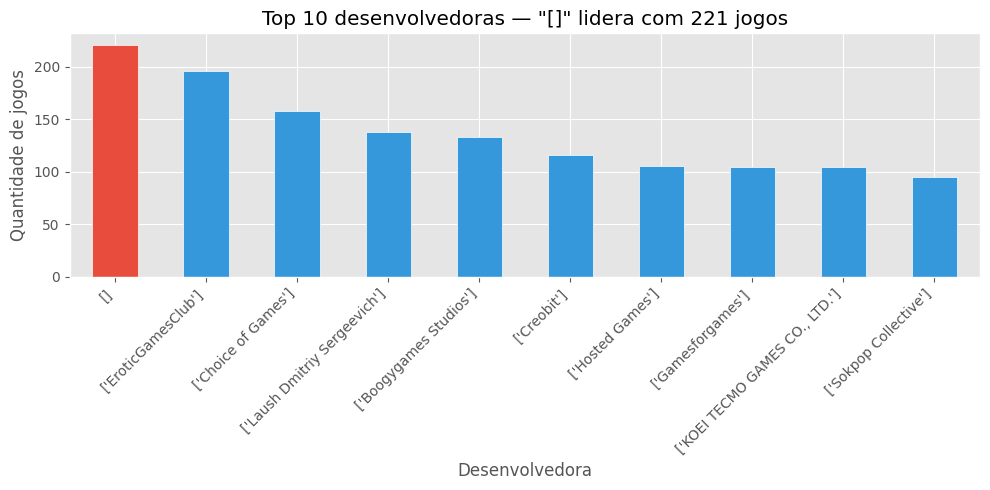

In [ ]:
top_dev = df['developers'].value_counts().head(10)

cores_dev = ['#e74c3c' if d == top_dev.index[0] else '#3498db' for d in top_dev.index]

plt.figure(figsize=(10, 5))
top_dev.plot(kind='bar', color=cores_dev, edgecolor='white')
plt.title(f'Top 10 desenvolvedoras — "{top_dev.index[0]}" lidera com {top_dev.iloc[0]} jogos')
plt.xlabel('Desenvolvedora')
plt.ylabel('Quantidade de jogos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Pergunta 6
Jogos com DLCs tendem a ter mais avaliações positivas do que jogos sem DLCs?

Jogos com DLC têm mediana de 100 avaliações positivas, enquanto jogos sem DLC têm mediana de apenas 7. Essa diferença é expressiva e indica uma associação clara: jogos com DLC tendem a ser mais populares e engajar mais a comunidade. No entanto, é importante não inverter a causalidade, jogos de sucesso atraem DLCs, não o contrário. Desenvolvedoras investem em DLC quando o jogo base já tem audiência. Ainda assim, a presença de DLC pode ser usada como um indicador indireto de saúde e longevidade de um título.

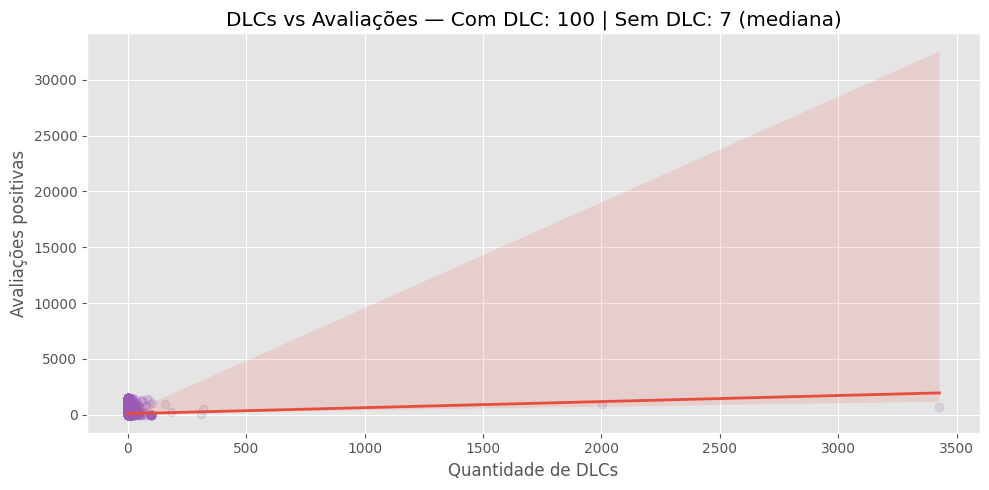

Mediana com DLC:  100
Mediana sem DLC:  7


In [ ]:
df_dlc = df[df['positive'] < df['positive'].quantile(0.95)]

mediana_com = df[df['dlc_count'] > 0]['positive'].median()
mediana_sem = df[df['dlc_count'] == 0]['positive'].median()

plt.figure(figsize=(10, 5))
sns.regplot(
    x='dlc_count',
    y='positive',
    data=df_dlc,
    scatter_kws={'alpha': 0.15, 'color': '#9b59b6'},
    line_kws={'color': '#e74c3c', 'linewidth': 2}
)
plt.title(f'DLCs vs Avaliações — Com DLC: {mediana_com:,.0f} | Sem DLC: {mediana_sem:,.0f} (mediana)')
plt.xlabel('Quantidade de DLCs')
plt.ylabel('Avaliações positivas')
plt.tight_layout()
plt.show()

print(f"Mediana com DLC:  {mediana_com:,.0f}")
print(f"Mediana sem DLC:  {mediana_sem:,.0f}")

#Pergunta 7  
Como o volume de lançamentos de jogos na Steam evoluiu ao longo dos anos?

O volume de lançamentos na Steam cresceu de forma consistente ao longo dos anos, atingindo o pico em 2024 com 18.282 jogos lançados. Esse crescimento exponencial reflete a abertura progressiva da plataforma após a introdução do Steam Direct em 2017, que substituiu o Greenlight e reduziu as barreiras de entrada. O crescimento não é necessariamente positivo para desenvolvedores: mais jogos lançados por ano significa mais concorrência e menor visibilidade orgânica para títulos individuais. A tendência aponta para um mercado cada vez mais saturado.

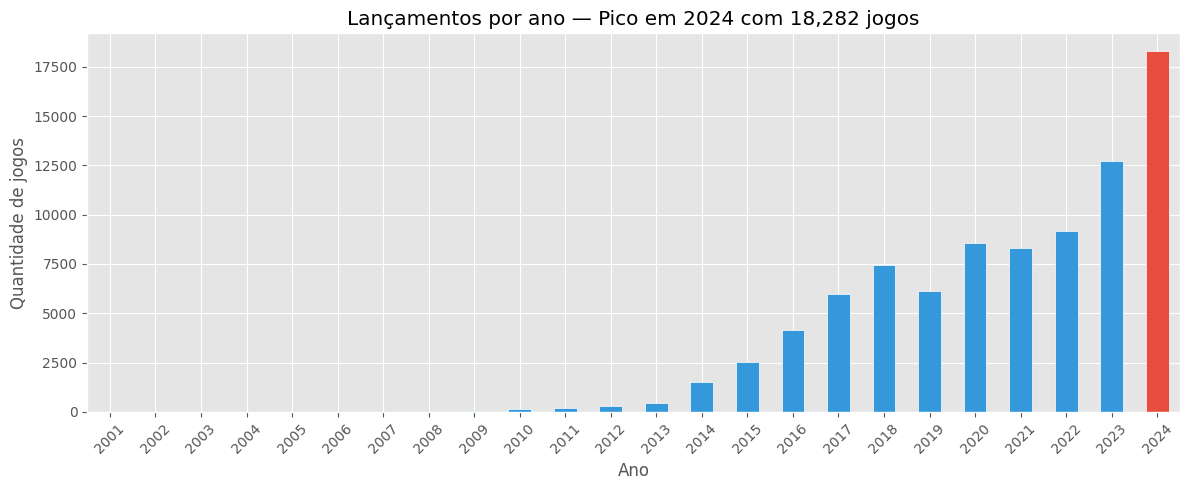

Ano com mais lançamentos: 2024 (18,282 jogos)


In [ ]:
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
anos = df['release_year'].dropna().astype(int)
anos = anos[(anos >= 2000) & (anos <= 2024)]
contagem = anos.value_counts().sort_index()

pico_ano = contagem.idxmax()
pico_val = contagem.max()

cores_ano = ['#e74c3c' if a == pico_ano else '#3498db' for a in contagem.index]

plt.figure(figsize=(12, 5))
contagem.plot(kind='bar', color=cores_ano, edgecolor='white')
plt.title(f'Lançamentos por ano — Pico em {pico_ano} com {pico_val:,} jogos')
plt.xlabel('Ano')
plt.ylabel('Quantidade de jogos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Ano com mais lançamentos: {pico_ano} ({pico_val:,} jogos)")

#Pergunta 8
Quais gêneros apresentam a maior média de avaliações positivas entre os jogadores?

O gênero "Photo Editing" lidera em média de avaliações positivas, o que parece contraintuitivo mas se explica pela baixa quantidade de jogos nessa categoria, poucos títulos com muitas avaliações elevam a média artificialmente. Esse é um efeito clássico de amostra pequena. Entre gêneros com volume relevante, categorias como Simulation e Strategy também aparecem bem posicionadas, sugerindo que jogadores nesses nichos são mais engajados e propensos a avaliar positivamente. A análise por média sem ponderação pelo volume de jogos deve ser interpretada com cautela.

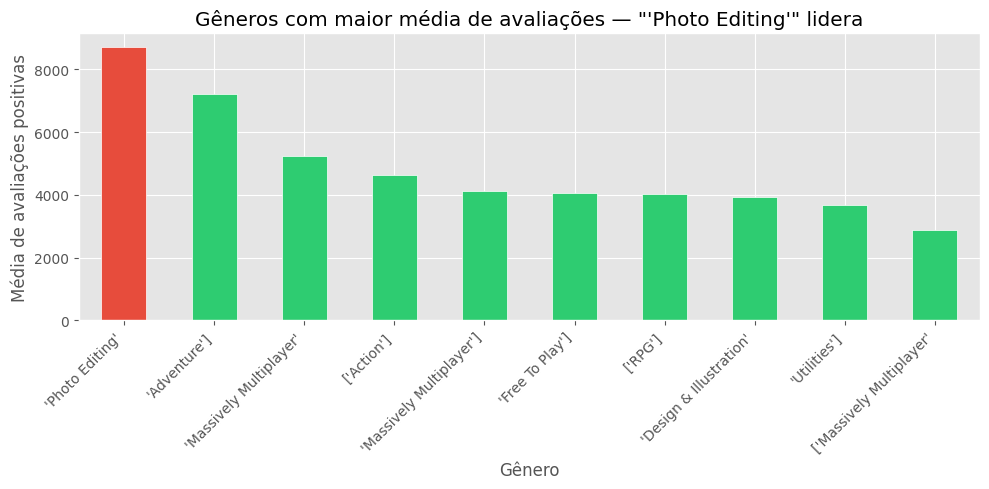

In [ ]:
df_exp = df.copy()
df_exp['genres'] = df_exp['genres'].str.split(',')
df_exp = df_exp.explode('genres')
df_exp['genres'] = df_exp['genres'].str.strip()


contagem_generos = df_exp['genres'].value_counts()
generos_validos = contagem_generos[contagem_generos >= 100].index
df_exp = df_exp[df_exp['genres'].isin(generos_validos)]

top_rated = (df_exp.groupby('genres')['positive']
             .mean()
             .sort_values(ascending=False)
             .head(10))

cores_r = ['#e74c3c' if g == top_rated.index[0] else '#2ecc71' for g in top_rated.index]

plt.figure(figsize=(10, 5))
top_rated.plot(kind='bar', color=cores_r, edgecolor='white')
plt.title(f'Gêneros com maior média de avaliações — "{top_rated.index[0]}" lidera')
plt.xlabel('Gênero')
plt.ylabel('Média de avaliações positivas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Análise extra - Matriz de Correlação
Quais gêneros apresentam a maior média de avaliações positivas entre os jogadores?

A matriz de correlação entre variáveis numéricas revela padrões importantes:

* **positive e recommendations** têm correlação de 0,93 — altamente esperada, pois
recomendações são baseadas nas avaliações.
* **positive e negative** têm correlação de 0,78 — jogos com muitas avaliações positivas também acumulam mais negativas, simplesmente porque têm mais avaliações no total (efeito de volume).
* **peak_ccu** (pico de usuários simultâneos) se correlaciona moderadamente com avaliações positivas (0,62), indicando que jogos populares tendem a ser bem avaliados — ou que jogos bem avaliados atraem mais jogadores.
* **price** tem correlações fracas com quase tudo, reforçando a conclusão da Pergunta 4.
* **average_playtime_forever** tem correlação de 0,43 com avaliações positivas, sugerindo que jogos com maior tempo de jogo acumulado tendem a ser mais bem avaliados — jogadores que ficam mais tempo tendem a ter experiências mais positivas.

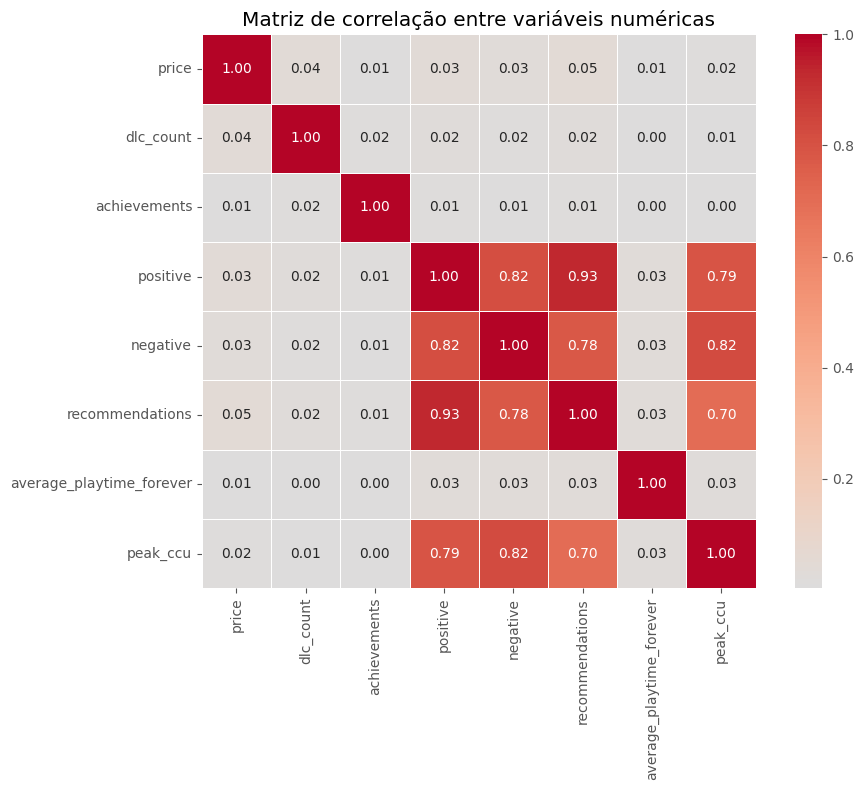


Correlações mais fortes com 'positive':
recommendations             0.932938
negative                    0.819434
peak_ccu                    0.792038
price                       0.034501
average_playtime_forever    0.031902
Name: positive, dtype: float64


In [ ]:
colunas = ['price', 'dlc_count', 'achievements',
           'positive', 'negative', 'recommendations',
           'average_playtime_forever', 'peak_ccu']

numeric = df[colunas].copy()
corr_matrix = numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Matriz de correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

print("\nCorrelações mais fortes com 'positive':")
print(corr_matrix['positive'].sort_values(ascending=False).drop('positive').head(5))